In [1]:
# 401(k) data: black-box interpretation — Random Forest
# Permutation VI, partial dependence, and SHAP for the same RF.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import shuffle

data_path = os.path.join('..', 'Data', 'restatw.dat')
data401k = pd.read_csv(data_path, sep=r'\s+')

columns_needed = ['net_tfa', 'e401', 'age', 'inc', 'educ', 'fsize', 'marr',
                  'twoearn', 'db', 'pira', 'hown']
data401k = data401k[columns_needed].dropna()

np.random.seed(8261977)
data401k = shuffle(data401k, random_state=8261977)
train = data401k.iloc[:8000]
test  = data401k.iloc[8000:]

X_train = train.drop(columns=['net_tfa']);  y_train = train['net_tfa']
X_test  = test.drop(columns=['net_tfa']);   y_test  = test['net_tfa']

rf_model = RandomForestRegressor(min_samples_leaf=60, random_state=8261977)
rf_model.fit(X_train, y_train)

print(f'train={len(train)}  test={len(test)}  features={X_train.shape[1]}')

train=8000  test=1915  features=10


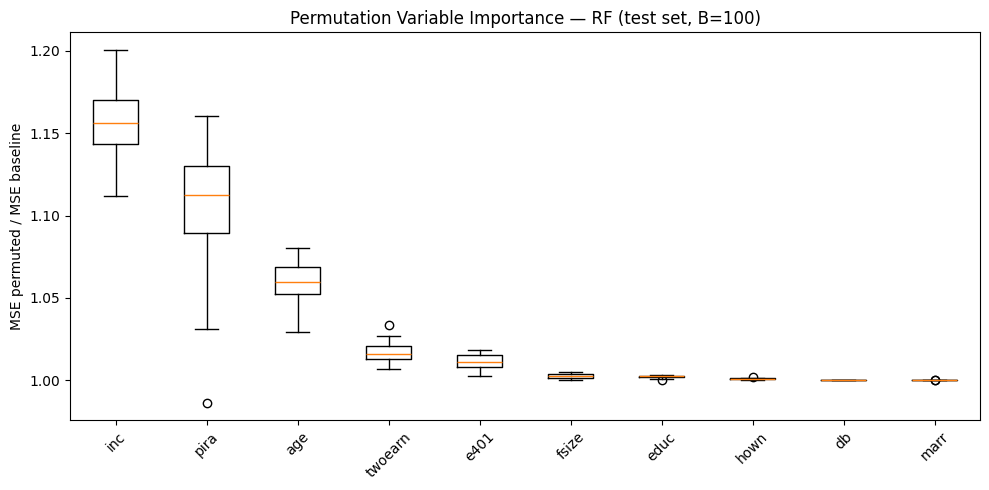

In [2]:
# Permutation variable importance, B=100 permutations on the test set.
# Reported as MSE_perm / MSE_baseline (loss of fit > 1 means variable matters).

def permutation_variable_importance(model, X, y, B=100, rng=None):
    rng = np.random.default_rng(rng)
    baseline_error = np.sum((y - model.predict(X))**2)
    n, p = X.shape
    errors = np.zeros((B, p))
    for b in range(B):
        for j in range(p):
            X_permuted = X.copy()
            X_permuted.iloc[:, j] = rng.permutation(X.iloc[:, j].values)
            errors[b, j] = np.sum((y - model.predict(X_permuted))**2)
    errors = errors / baseline_error
    return {'e0': baseline_error, 'eB': errors, 'VI': errors.mean(axis=0)}

VI_rf = permutation_variable_importance(rf_model, X_test, y_test, B=100, rng=8261977)
vi_sorted_idx = np.argsort(-VI_rf['VI'])

plt.figure(figsize=(10, 5))
plt.boxplot(VI_rf['eB'][:, vi_sorted_idx])
plt.xticks(np.arange(1, X_test.shape[1] + 1), X_test.columns[vi_sorted_idx], rotation=45)
plt.ylabel('MSE permuted / MSE baseline')
plt.title('Permutation Variable Importance — RF (test set, B=100)')
plt.tight_layout()
plt.show()

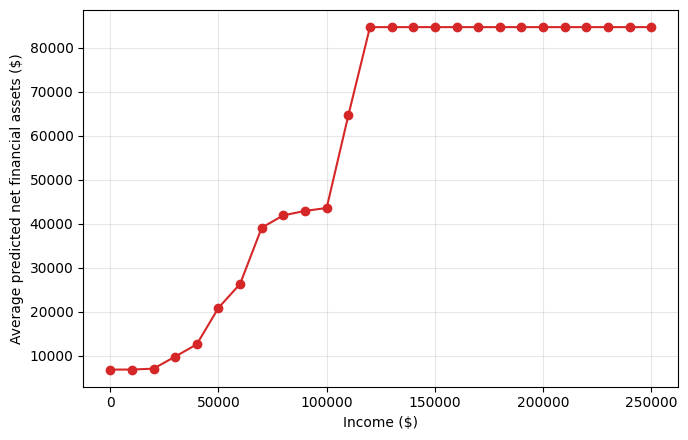

PD pira = 0:      8053    pira = 1:     35051
PD e401 = 0:     15609    e401 = 1:     21042


In [3]:
# Partial dependence on income (continuous) and on pira / e401 (binary).
# Saves the income PDP as a PDF for use in the slide.

def partial_dependence(model, eval_points, var_name, X):
    h = []
    for point in eval_points:
        X_temp = X.copy()
        X_temp[var_name] = point
        h.append(np.mean(model.predict(X_temp)))
    return np.array(h)

X_full = data401k.drop(columns=['net_tfa'])
fig_dir = os.path.join('..', 'Slides', 'figures')
os.makedirs(fig_dir, exist_ok=True)

# Continuous: income, evaluated on a $10k grid up to $250k.
income_values = np.arange(0, 250001, 10000)
h_inc = partial_dependence(rf_model, income_values, 'inc', X_full)

plt.figure(figsize=(7, 4.5))
plt.plot(income_values, h_inc, marker='o', color='C3', linewidth=1.5)
plt.xlabel('Income ($)')
plt.ylabel('Average predicted net financial assets ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '401k_pdp_inc.pdf'), bbox_inches='tight')
plt.show()

# Binary: pira (private retirement account ownership) and e401 (eligibility).
h_pira = partial_dependence(rf_model, [0, 1], 'pira', X_full)
h_elig = partial_dependence(rf_model, [0, 1], 'e401', X_full)

print(f'PD pira = 0:  {h_pira[0]:8.0f}    pira = 1:  {h_pira[1]:8.0f}')
print(f'PD e401 = 0:  {h_elig[0]:8.0f}    e401 = 1:  {h_elig[1]:8.0f}')

In [4]:
# SHAP values for the RF, computed exactly via TreeExplainer on the full test set.
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)   # Explanation object (n_test x p)

expected = float(np.asarray(explainer.expected_value).item())
print('shap version:', shap.__version__)
print('expected value E[f(X)]:', expected)
print('shap_values shape:', shap_values.values.shape)

# Sanity check: f(x_i) = E[f(X)] + sum_j phi_j(x_i)
recon = expected + shap_values.values[0].sum()
print(f'reconstruction (obs 0): {recon:.4f}   model pred: {rf_model.predict(X_test.iloc[[0]])[0]:.4f}')

shap version: 0.51.0
expected value E[f(X)]: 18015.102917500004
shap_values shape: (1915, 10)
reconstruction (obs 0): 95930.8626   model pred: 95930.8626


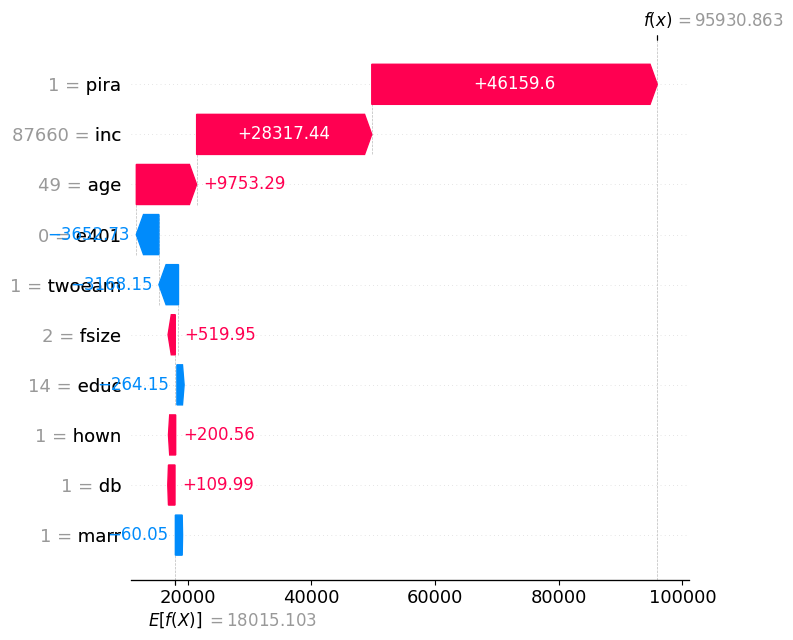

observation 0:  predicted = 95931   actual = 33249


In [5]:
# SHAP waterfall plot for a single observation (used in slide 'SHAP Decomposition').
fig_dir = os.path.join('..', 'Slides', 'figures')
os.makedirs(fig_dir, exist_ok=True)

obs_idx = 0
fig = plt.figure()
shap.plots.waterfall(shap_values[obs_idx], max_display=10, show=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '401k_shap_waterfall.pdf'), bbox_inches='tight')
plt.show()

print(f'observation {obs_idx}:  predicted = {rf_model.predict(X_test.iloc[[obs_idx]])[0]:.0f}'
      f'   actual = {y_test.iloc[obs_idx]:.0f}')

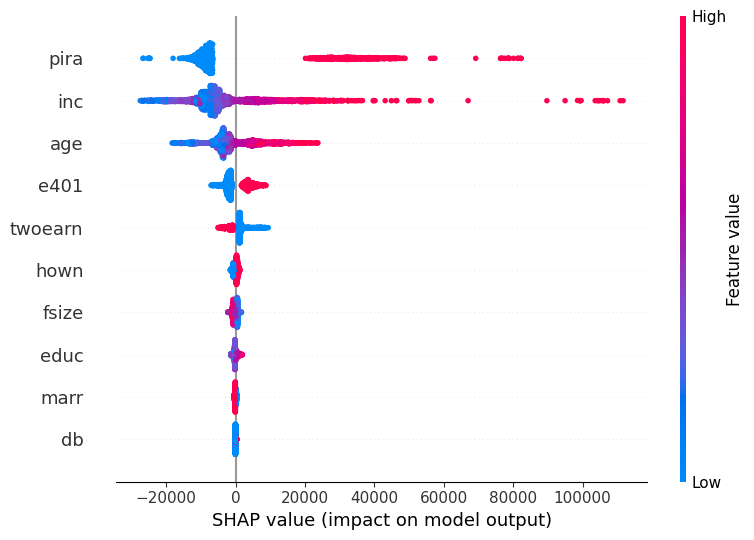

In [6]:
# SHAP beeswarm across the test set (used in slide 'SHAP Across Observations').
fig = plt.figure()
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '401k_shap_beeswarm.pdf'), bbox_inches='tight')
plt.show()

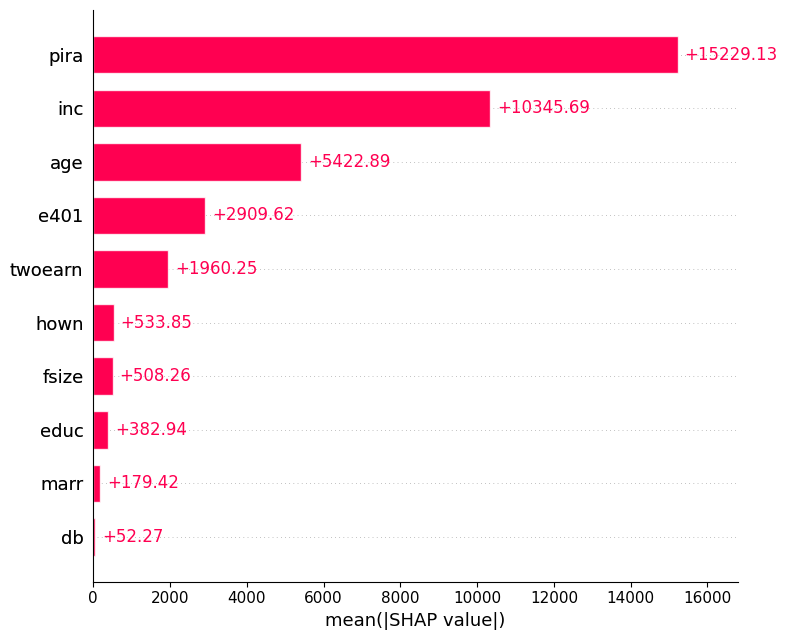

mean |SHAP| (sorted):
      pira   15229.1
       inc   10345.7
       age    5422.9
      e401    2909.6
   twoearn    1960.2
      hown     533.8
     fsize     508.3
      educ     382.9
      marr     179.4
        db      52.3


In [7]:
# SHAP variable importance: mean(|SHAP|) bar (used in slide 'SHAP Variable Importance').
fig = plt.figure()
shap.plots.bar(shap_values, max_display=10, show=False)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, '401k_shap_importance.pdf'), bbox_inches='tight')
plt.show()

mean_abs = np.abs(shap_values.values).mean(axis=0)
order = np.argsort(-mean_abs)
print('mean |SHAP| (sorted):')
for j in order:
    print(f'  {X_test.columns[j]:>8s}  {mean_abs[j]:8.1f}')